# Particle in a One-Dimensional Box

The particle in a one-dimensional box is the simplest quantum-mechanical
boundary-value problem. It introduces the computational structure

$$
\boxed{
\text{domain}
+
\text{boundary conditions}
+
\text{operators}
\longrightarrow
\text{matrix eigenvalue problem}.
}
$$

A particle of mass $m$ is confined to the interval

$$
0\leq x\leq L,
$$

where $L$ is the length of the box.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.constants import hbar, electron_mass, electron_volt
from scipy.linalg import eigh

from physkit.core.grids import CartesianGrid1D
from physkit.core.boundaries import (
    AxisBoundaryConditions,
    DirichletBoundaryCondition,
)
from physkit.numerics.differentiation.laplacian import (
    FiniteDifferenceLaplacian1D,
)

## Physical Model

The potential-energy function is

$$
V(x)
=
\begin{cases}
0, & 0<x<L,\\[4pt]
\infty, & x\leq 0\text{ or }x\geq L.
\end{cases}
$$

The infinite exterior potential prevents the particle from leaving the
interval. Its effect is imposed through the Dirichlet boundary conditions

$$
\boxed{
\psi(0)=0,
\qquad
\psi(L)=0.
}
$$

The boundary values are prescribed values. They are therefore not unknown
degrees of freedom in the numerical eigenvalue problem.

## Analytical Solution

Inside the box,

$$
V(x)=0.
$$

The Hamiltonian is therefore purely kinetic:

$$
\hat H
=
\hat T
=
-\frac{\hbar^2}{2m}
\frac{\mathrm d^2}{\mathrm dx^2}.
$$

The time-independent Schrödinger equation is

$$
\hat H\lvert\psi_n\rangle
=
E_n\lvert\psi_n\rangle.
$$

In the position representation,

$$
-\frac{\hbar^2}{2m}
\frac{\mathrm d^2\psi_n(x)}{\mathrm dx^2}
=
E_n\psi_n(x),
$$

subject to

$$
\psi_n(0)=\psi_n(L)=0.
$$

The normalized eigenfunctions are

$$
\boxed{
\psi_n(x)
=
\sqrt{\frac{2}{L}}
\sin\left(\frac{n\pi x}{L}\right)
},
\qquad
n=1,2,3,\ldots
$$

and the energy eigenvalues are

$$
\boxed{
E_n
=
\frac{\hbar^2\pi^2n^2}{2mL^2}
}.
$$

class Piab1DSolver:

class Piab1DResult:

class Piab1DAnalyticalResult(Piab1DResult):
class Piab1DAnalyticalSolver(Piab1DSolver):
    @property
    def result(self) -> Piab1DAnalyticalResult

class Piab1DNumericalResult(Piab1DResult):
class Piab1DNumericalSolver(Piab1DSolver):
    @property
    def result(self) -> Piab1DNumericalResult



## Numerical Parameters

In [2]:
box_length = 1.0e-9
particle_mass = electron_mass
Nx = 201
Neigen = 5

x_lower = 0.
x_upper = x_lower + box_length


We use SI units:

- $L$: box length in meters
- $m$: particle mass in kilograms
- $E$: energy in joules
- $\psi(x)$: wavefunction in $\mathrm{m}^{-1/2}$

The energy eigenvalues will be displayed in electronvolts using

$$
1\ \mathrm{eV}
=
1.602176634\times 10^{-19}\ \mathrm{J}.
$$

## Cartesian Grid

The continuous interval $[0,L]$ is represented by the grid

$$
x_j=j\Delta x,
\qquad
j=0,1,\ldots,N-1,
$$

where

$$
\Delta x=\frac{L}{N-1}.
$$

The grid includes both endpoints because the boundary conditions are
defined at $x=0$ and $x=L$.

In [3]:
grid = CartesianGrid1D(
    x_lower=x_lower,
    x_upper=x_upper,
    Nx=Nx,
    endpoint=True,
)

x = grid.x.values

print(f"Number of grid points: {grid.x.N}")
print(f"Box length:           {grid.x.length:.3e} m")
print(f"Grid spacing:         {grid.x.delta:.3e} m")

Number of grid points: 201
Box length:           1.000e-09 m
Grid spacing:         5.000e-12 m


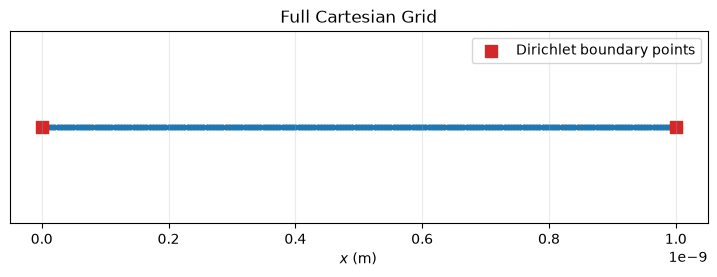

In [4]:
fig, ax = plt.subplots(figsize=(9, 2.5))

ax.scatter(
    x,
    np.zeros_like(x),
    s=12,
    color="tab:blue",
)

ax.scatter(
    [x[0], x[-1]],
    [0.0, 0.0],
    s=70,
    marker="s",
    color="tab:red",
    label="Dirichlet boundary points",
)

ax.set_xlabel(r"$x$ (m)")
ax.set_yticks([])
ax.set_title("Full Cartesian Grid")
ax.legend()
ax.grid(alpha=0.25)

plt.show()

## Boundary Conditions and the Active State Space

The full grid contains the coordinate samples
$$
\{x_0,x_1,\ldots,x_{N-2},x_{N-1}\}.
$$
Using the same indieces, a wave function $\langle x | \psi \rangle = \psi(x)$, is defined as
$$
\boldsymbol{\psi}
= \begin{bmatrix}
  \psi(x_0) & \psi(x_2) & \cdots & \psi(x_{N-1})
\end{bmatrix}^\mathsf{T}
$$

### Boundary Conditions
The boundary values satisfy Dirichlet boundary conditions:
$$
\psi(x_0)=\psi(x_{N-1})=0.
$$

### Active Set
We define the active set on the interior samples which are unknown.

Only the interior samples are unknown:
$$\begin{align}
\boldsymbol{\psi}_\text{active}
= \begin{bmatrix}
  \psi(x_1) & \psi(x_2) & \cdots & \psi(x_{N-2})
\end{bmatrix}^\mathsf{T}
\end{align}$$

The active discrete state space therefore has dimension

$$
N_\text{active}=N-2.
$$

The full grid describes the geometry. The active set describes the degrees
of freedom on which the operators act.

In [5]:
boundary_conditions = AxisBoundaryConditions(
    lower=DirichletBoundaryCondition(value=0.0),
    upper=DirichletBoundaryCondition(value=0.0),
)

## Finite-Difference Laplacian

At an interior grid point $x_j$, the second derivative is approximated by

$$
\frac{\mathrm d^2\psi}{\mathrm dx^2}\bigg|_{x_j}
\approx
\frac{
\psi_{j-1}
-2\psi_j
+\psi_{j+1}
}{
(\Delta x)^2
}.
$$

The active-space Laplacian matrix is

$$
D^{(2)}_A
=
\frac{1}{(\Delta x)^2}
\begin{bmatrix}
-2 & 1 & 0 & \cdots & 0\\
1 & -2 & 1 & \ddots & \vdots\\
0 & 1 & -2 & \ddots & 0\\
\vdots & \ddots & \ddots & \ddots & 1\\
0 & \cdots & 0 & 1 & -2
\end{bmatrix}.
$$

The matrix acts only on the active state vector:

$$
D^{(2)}_A\boldsymbol{\psi}_A
\approx
\left.
\frac{\mathrm d^2\psi}{\mathrm dx^2}
\right|_A.
$$

In [6]:
laplacian = FiniteDifferenceLaplacian1D(
    grid=grid,
    boundary_conditions=boundary_conditions,
)

active = laplacian.active_set
laplacian_matrix = laplacian.matrix

x_active = grid.x.values[active.indices]

print(f"Full-grid dimension:   {grid.x.N}")
print(f"Active-space dimension: {active.size}")
print(f"Laplacian shape:        {laplacian_matrix.shape}")

Full-grid dimension:   201
Active-space dimension: 199
Laplacian shape:        (199, 199)


## Hamiltonian Matrix

The kinetic-energy operator is

$$
\hat T
=
-\frac{\hbar^2}{2m}\nabla^2.
$$

Its active-space matrix representation is

$$
T_A
=
-\frac{\hbar^2}{2m}D_A^{(2)}.
$$

Since $V(x)=0$ inside the box,

$$
V_A=0.
$$

The Hamiltonian matrix is therefore

$$
\boxed{
H_A
=
T_A+V_A
=
-\frac{\hbar^2}{2m}D_A^{(2)}.
}
$$

In [7]:
kinetic_matrix = (
    -(hbar**2) / (2.0 * particle_mass)
) * laplacian_matrix

potential_matrix = np.zeros(
    shape=kinetic_matrix.shape,
    dtype=float,
)

hamiltonian_matrix = (
    kinetic_matrix.toarray()
    + potential_matrix
)

In [8]:
hermiticity_error = np.linalg.norm(
    hamiltonian_matrix
    - hamiltonian_matrix.conj().T
)

print(f"Hermiticity error: {hermiticity_error:.3e}")

Hermiticity error: 0.000e+00


## Matrix Eigenvalue Problem

The continuous eigenvalue equation

$$
\hat H\lvert\psi_n\rangle
=
E_n\lvert\psi_n\rangle
$$

becomes the finite-dimensional matrix eigenvalue problem

$$
\boxed{
H_A\mathbf c_n
=
E_n^{(N)}\mathbf c_n.
}
$$

Here,

- $H_A$ is the Hamiltonian matrix on the active state space;
- $\mathbf c_n$ contains the interior wavefunction samples;
- $E_n^{(N)}$ is the numerical approximation to the $n$th energy;
- $N$ records the dependence on spatial resolution.

In [10]:
eigenvalues, eigenvectors = eigh(
    hamiltonian_matrix,
    subset_by_index=(
        0,
        Neigen - 1,
    ),
)

energies_numerical = eigenvalues

## Continuous Normalization

The eigensolver uses the Euclidean normalization

$$
\mathbf c_n^\dagger\mathbf c_n=1.
$$

A discretized wavefunction should instead approximate the continuous
normalization condition

$$
\int_0^L |\psi_n(x)|^2\,\mathrm dx=1.
$$

For a uniform grid,

$$
\int_0^L |\psi_n(x)|^2\,\mathrm dx
\approx
\Delta x\,
\boldsymbol{\psi}_{n,A}^\dagger
\boldsymbol{\psi}_{n,A}.
$$

The sampled eigenvector must therefore be normalized using the spatial
quadrature measure.

In [12]:
psi_active_array = eigenvectors.copy()

for state_index in range(Neigen):
    norm = np.sqrt(
        np.trapezoid(
            np.abs(psi_active_array[:, state_index]) ** 2,
            x=x_active,
        )
    )

    psi_active_array[:, state_index] /= norm

## Full-Grid Reconstruction

The eigensolver returns only the active degrees of freedom. To plot the
physical wavefunction on the complete interval, the prescribed boundary
values must be restored:

$$
\boldsymbol{\psi}_n
=
\begin{bmatrix}
0\\
\boldsymbol{\psi}_{n,A}\\
0
\end{bmatrix}.
$$

Equivalently, if $R_A$ is the restriction matrix,

$$
\boldsymbol{\psi}_{n,A}
=
R_A\boldsymbol{\psi}_n,
$$

then its transpose embeds an active vector into the full grid:

$$
\boldsymbol{\psi}_n
=
R_A^{\mathsf T}\boldsymbol{\psi}_{n,A}.
$$

## Full-Grid Reconstruction

The eigensolver returns only the active degrees of freedom. To plot the
physical wavefunction on the complete interval, the prescribed boundary
values must be restored:

$$
\boldsymbol{\psi}_n
= \begin{bmatrix}
  0 & \boldsymbol{\psi}_{n,A} & 0
\end{bmatrix}^\mathsf{T}
$$

Equivalently, if $R_A$ is the restriction matrix,

$$
\boldsymbol{\psi}_{n,A}
  = R_A\boldsymbol{\psi}_n,
$$

then its transpose embeds an active vector into the full grid:

$$
\boldsymbol{\psi}_n
  = R_A^{\mathsf T}\boldsymbol{\psi}_{n,A}.
$$

In [18]:
psi_array_numerical = np.zeros(
    (grid.x.N, Neigen,),
    dtype=float
)

psi_array_numerical[
    active.indices,
    :,
] = psi_active_array

In [19]:
quantum_numbers = np.arange(
    1, Neigen + 1
)

energies_analytical = (
    hbar**2 * np.pi**2 * quantum_numbers**2
    / ( 2.0 * particle_mass * box_length**2)
)

psi_array_analytical = np.zeros_like(
    psi_array_numerical
)

for state_index, n in enumerate(quantum_numbers):
    psi_array_analytical[:, state_index] = (
        np.sqrt(2.0 / box_length)
        * np.sin( n * np.pi * x / box_length)
    )

## Compare Energy Eigenvalues

In [20]:
relative_errors = np.abs(
    (
        energies_numerical
        - energies_analytical
    )
    / energies_analytical
)

print(
    f"{'n':>3}"
    f"{'Analytical (eV)':>20}"
    f"{'Numerical (eV)':>20}"
    f"{'Relative error':>20}"
)

for state_index, n in enumerate(quantum_numbers):
    print(
        f"{n:>3d}"
        f"{energies_analytical[state_index] / electron_volt:>20.8f}"
        f"{energies_numerical[state_index] / electron_volt:>20.8f}"
        f"{relative_errors[state_index]:>20.3e}"
    )

  n     Analytical (eV)      Numerical (eV)      Relative error
  1          0.37603016          0.37602243           2.056e-05
  2          1.50412065          1.50399694           8.224e-05
  3          3.38427146          3.38364523           1.850e-04
  4          6.01648259          6.01450351           3.289e-04
  5          9.40075405          9.39592266           5.139e-04


For the second-order central-difference approximation, the numerical
eigenvalues satisfy the exact discrete relation

$$
E_n^{(N)}
=
\frac{2\hbar^2}{m(\Delta x)^2}
\sin^2\left(
\frac{n\pi}{2(N-1)}
\right).
$$

In the continuum limit,

$$
\sin z\approx z,
$$

so that

$$
E_n^{(N)}
\longrightarrow
\frac{\hbar^2\pi^2n^2}{2mL^2}
=
E_n.
$$

The finite-difference model therefore approaches the analytical
particle-in-a-box spectrum as

$$
\Delta x\rightarrow 0.
$$

## Compare the Wave Functions

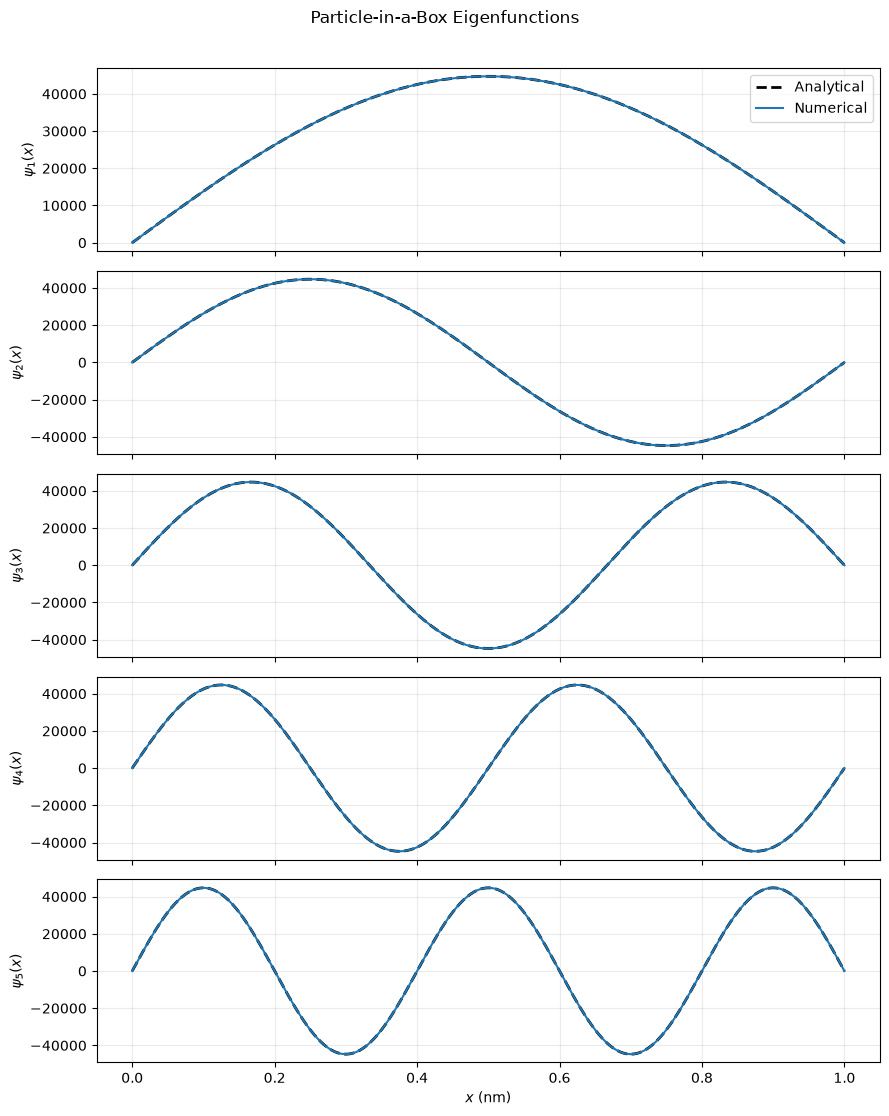

In [22]:
fig, axes = plt.subplots(
    Neigen, 1,
    figsize=(9, 2.2 * Neigen),
    sharex=True,
)

for state_index, ax in enumerate(axes):
    numerical = psi_array_numerical[:, state_index]
    analytical = psi_array_analytical[:, state_index]

    overlap = np.trapezoid(
        analytical * numerical,
        x=x,
    )

    if overlap < 0.0:
        numerical = -numerical

    ax.plot(
        x * 1.0e9,
        analytical,
        color="black",
        linestyle="--",
        linewidth=2.0,
        label="Analytical",
    )

    ax.plot(
        x * 1.0e9,
        numerical,
        color="tab:blue",
        linewidth=1.5,
        label="Numerical",
    )

    ax.set_ylabel(
        rf"$\psi_{state_index + 1}(x)$"
    )

    ax.grid(alpha=0.25)

axes[0].legend()
axes[-1].set_xlabel(r"$x$ (nm)")

fig.suptitle(
    "Particle-in-a-Box Eigenfunctions",
    y=1.01,
)

plt.tight_layout()
plt.show()